In [44]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

## Dataset Overview

The dataset contains **270 patient observations** and **13 predictive features**. 
The target variable indicates whether heart disease is absent or present.

The features include demographic information, clinical measurements,
exercise-related measurements, and electrocardiographic observations.

## Feature Description

| Feature | Description | Type |
|---|---|---|
| `age` | Age of the patient in years | Numerical |
| `sex` | Sex of the patient | Binary |
| `cp` | Chest pain type | Categorical |
| `trestbps` | Resting blood pressure (mm Hg) | Numerical |
| `chol` | Serum cholesterol level (mg/dl) | Numerical |
| `fbs` | Whether fasting blood sugar is > 120 mg/dl | Binary |
| `restecg` | Resting electrocardiographic results | Categorical |
| `thalach` | Maximum heart rate achieved | Numerical |
| `exang` | Exercise-induced angina | Binary |
| `oldpeak` | ST depression induced by exercise relative to rest | Numerical |
| `slope` | Slope of the peak exercise ST segment | Ordinal |
| `ca` | Number of major vessels colored by fluoroscopy | Ordinal |
| `thal` | Thalassemia type | Categorical |
| `target` | Heart disease diagnosis: 1 = absence, 2 = presence | Binary |

In [32]:
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(
    "../data/heart.dat",
    sep=r"\s+",
    names=columns
)

In [38]:
#eda
print('Shape: ',df.shape,"\n")
print('First 5 rows:\n',df.head(),"\n")
print("Info: ",(df.info(),"\n"))
print("Null Values: ",df.isnull().sum(),"\n")
print("Duplicates: ",df.duplicated().sum(),"\n")
print("Description: ",df.describe().T,"\n")
print("Target Classes: ",df["target"].value_counts(),"\n")

Shape:  (270, 14) 

First 5 rows:
     age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  70.0  1.0  4.0     130.0  322.0  0.0      2.0    109.0    0.0      2.4   
1  67.0  0.0  3.0     115.0  564.0  0.0      2.0    160.0    0.0      1.6   
2  57.0  1.0  2.0     124.0  261.0  0.0      0.0    141.0    0.0      0.3   
3  64.0  1.0  4.0     128.0  263.0  0.0      0.0    105.0    1.0      0.2   
4  74.0  0.0  2.0     120.0  269.0  0.0      2.0    121.0    1.0      0.2   

   slope   ca  thal  target  
0    2.0  3.0   3.0       2  
1    2.0  0.0   7.0       1  
2    1.0  0.0   7.0       2  
3    2.0  1.0   7.0       1  
4    1.0  1.0   3.0       1   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       270 non-null    float64
 1   sex       270 non-null    float64
 2   cp        270 non-null    float64
 3   trestbps  270 n

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'oldpeak'}>, <Axes: >]], dtype=object)

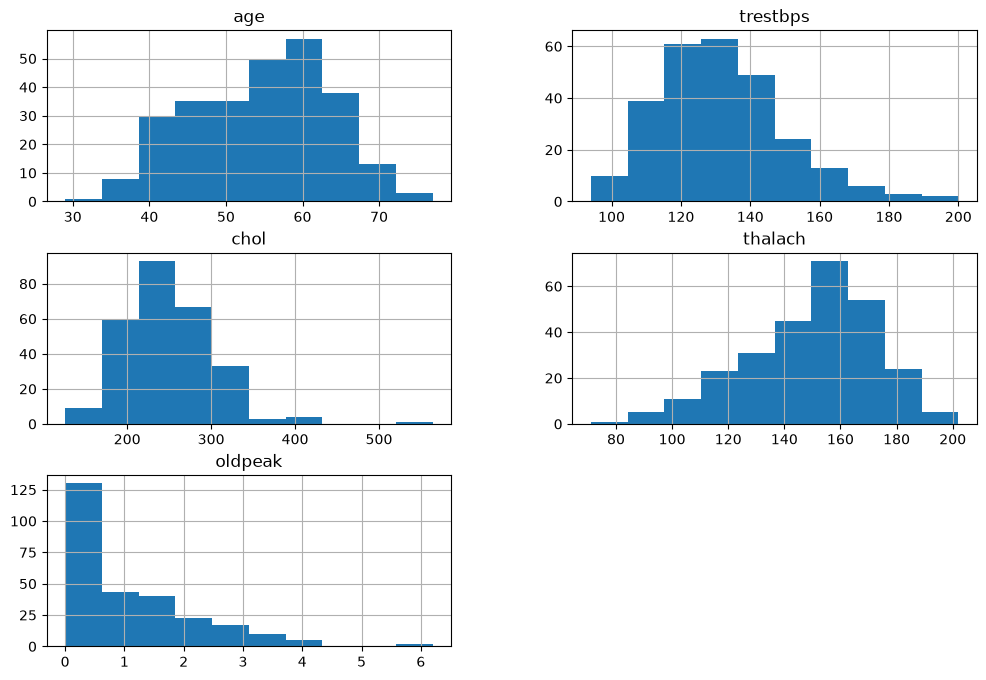

In [39]:
#numeric feature dist.
numerical = ["age", "trestbps", "chol", "thalach", "oldpeak"]

df[numerical].hist(figsize=(12, 8))

In [41]:
#categorical feature dist.
categorical = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

for col in categorical:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


sex
sex
0.0     87
1.0    183
Name: count, dtype: int64

cp
cp
1.0     20
2.0     42
3.0     79
4.0    129
Name: count, dtype: int64

fbs
fbs
0.0    230
1.0     40
Name: count, dtype: int64

restecg
restecg
0.0    131
1.0      2
2.0    137
Name: count, dtype: int64

exang
exang
0.0    181
1.0     89
Name: count, dtype: int64

slope
slope
1.0    130
2.0    122
3.0     18
Name: count, dtype: int64

ca
ca
0.0    160
1.0     58
2.0     33
3.0     19
Name: count, dtype: int64

thal
thal
3.0    152
6.0     14
7.0    104
Name: count, dtype: int64


In [42]:
#feature vs target
df.groupby("target")[numerical].mean().T

target,1,2
age,52.706667,56.591667
trestbps,128.866667,134.441667
chol,244.213333,256.466667
thalach,158.333333,138.858333
oldpeak,0.622667,1.584167


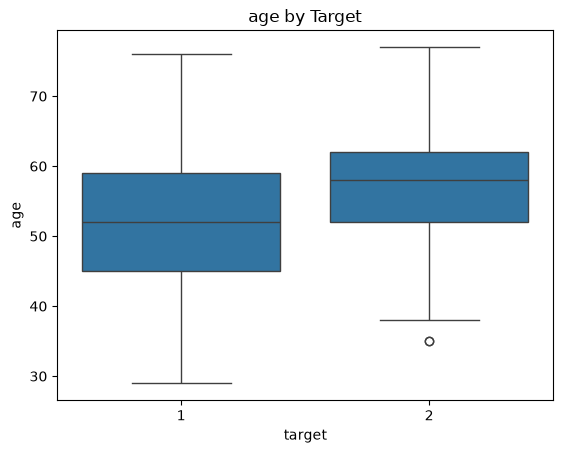

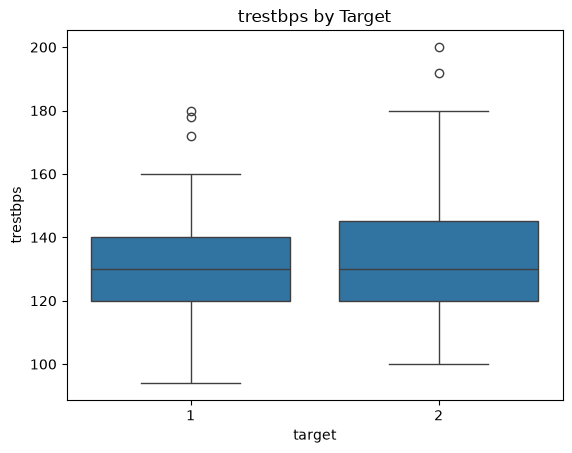

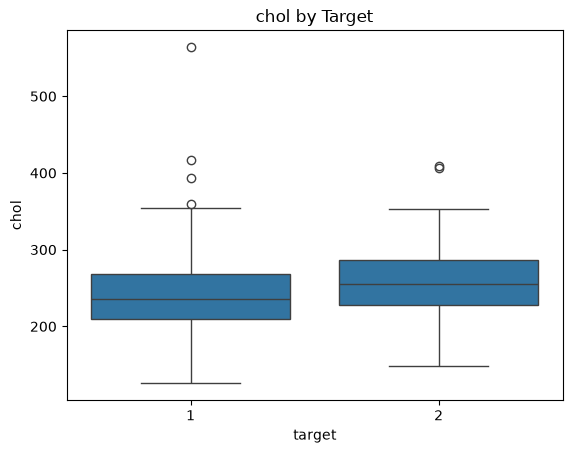

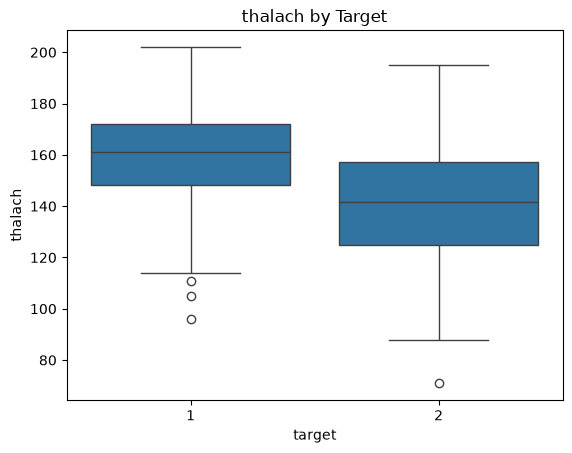

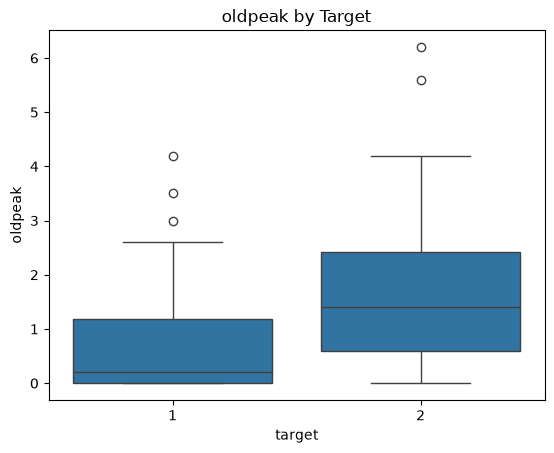

In [45]:
for col in numerical:
    sns.boxplot(data=df, x="target", y=col)
    plt.title(f"{col} by Target")
    plt.show()

In [46]:
#seperate target from features
X = df.drop("target", axis=1)
y = (df["target"] == 2).astype(int)

In [49]:
#split data into training and testing, with 80% and 20%
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [50]:
#preprocessing
numerical = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

In [52]:
from sklearn.compose import ColumnTransformer    #numerical
from sklearn.preprocessing import StandardScaler, OneHotEncoder    #categorical

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
])

In [53]:
#Logistic Regression 
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwe

In [54]:
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.83      0.88        30
           1       0.81      0.92      0.86        24

    accuracy                           0.87        54
   macro avg       0.87      0.88      0.87        54
weighted avg       0.88      0.87      0.87        54



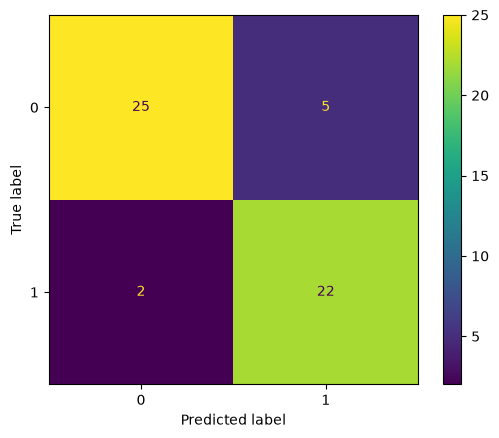

In [55]:
#generate confusion matrix for logistic regression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.show()

In [56]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.83      0.85        30
           1       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



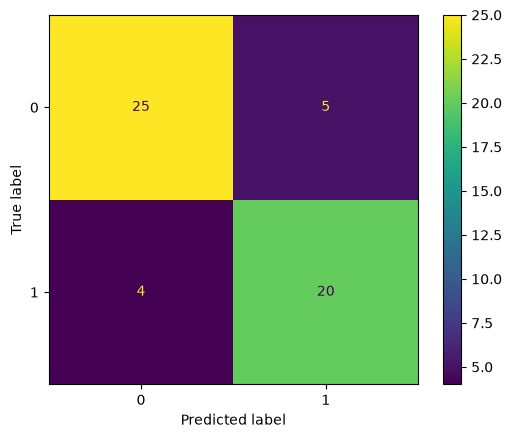

In [57]:
#generate confusion matrix for RandomForestClassifier
cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(cm).plot()
plt.show()

In [58]:
#cross validation
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [59]:
scoring = ["accuracy", "precision", "recall", "f1"]

#logistic regression
log_cv = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

#random forest
rf_cv = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [60]:
results = pd.DataFrame({
    "Logistic Regression": {
        metric: log_cv[f"test_{metric}"].mean()
        for metric in scoring
    },
    "Random Forest": {
        metric: rf_cv[f"test_{metric}"].mean()
        for metric in scoring
    }
})

print(results)    #logistic regression wins with more accuracy

           Logistic Regression  Random Forest
accuracy              0.828436       0.814482
precision             0.833957       0.804273
recall                0.770526       0.780526
f1                    0.798192       0.788425


In [63]:
#false positives are mroe desirable compared to false negatives, so we try lowering threshold
y_prob = model.predict_proba(X_test)[:, 1]
threshold = 0.40

y_pred_threshold = (y_prob >= threshold).astype(int)
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_threshold))
print(confusion_matrix(y_test, y_pred_threshold))

              precision    recall  f1-score   support

           0       0.92      0.77      0.84        30
           1       0.76      0.92      0.83        24

    accuracy                           0.83        54
   macro avg       0.84      0.84      0.83        54
weighted avg       0.85      0.83      0.83        54

[[23  7]
 [ 2 22]]


In [64]:
for threshold in [0.50, 0.45, 0.40, 0.35, 0.30]:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, y_pred_threshold))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.93      0.83      0.88        30
           1       0.81      0.92      0.86        24

    accuracy                           0.87        54
   macro avg       0.87      0.88      0.87        54
weighted avg       0.88      0.87      0.87        54


Threshold: 0.45
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      0.77      0.84        30
           1       0.76      0.92      0.83        24

    accuracy                           0.83        54
   macro avg       0.84      0.84      0.83        54
weighted avg       0.85  

### lowering threshold doesnt seem to do much other than sacrificing precision, so we maintain 0.5 precision and finalize on logistic regression

Accuracy : 0.8703703703703703
Precision: 0.8148148148148148
Recall   : 0.9166666666666666
F1       : 0.8627450980392157
ROC-AUC  : 0.9138888888888889


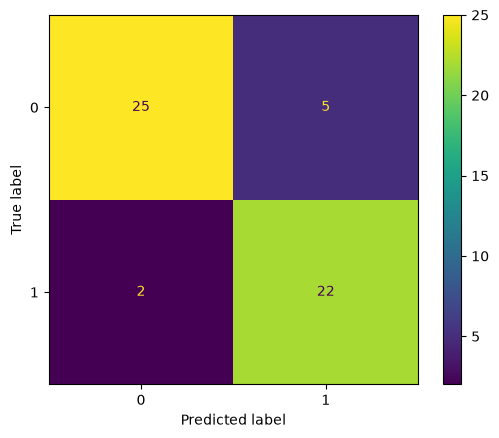

In [73]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)